In [1]:
#Import Librarys 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,mean_absolute_error,root_mean_squared_error,r2_score,mean_squared_error

In [2]:
#Import the File

try:
    df = pd.read_csv("Data_Sheet/ola_driver.csv")
except FileNotFoundError as e:
    print(f"Error {e}.")
except Exception as e1:
    print(f"Error {e1}.")

In [3]:
"""
# Define Problem Statement and Perform Exploratory Data Analysis (10 points)
-> Definition of Problem:- Understand the challenge of driver attrition and its impact on Ola.

# Data Exploration:
-> Check data shape, data types, and convert categorical attributes if necessary.
-> Detect missing values and prepare for simple imputation.
-> Perform statistical summary to understand data distribution.
"""

'\n# Define Problem Statement and Perform Exploratory Data Analysis (10 points)\n-> Definition of Problem:- Understand the challenge of driver attrition and its impact on Ola.\n\n# Data Exploration:\n-> Check data shape, data types, and convert categorical attributes if necessary.\n-> Detect missing values and prepare for simple imputation.\n-> Perform statistical summary to understand data distribution.\n'

In [4]:
print(f"Into the shape there is total {df.shape[0]} rows , and {df.shape[1]} number of columns is there.\n")

Into the shape there is total 19104 rows , and 14 number of columns is there.



In [5]:
print("Lets see the Data types of the all columns.\n",df.dtypes)

Lets see the Data types of the all columns.
 Unnamed: 0                int64
MMM-YY                   object
Driver_ID                 int64
Age                     float64
Gender                  float64
City                     object
Education_Level           int64
Income                    int64
Dateofjoining            object
LastWorkingDate          object
Joining Designation       int64
Grade                     int64
Total Business Value      int64
Quarterly Rating          int64
dtype: object


In [6]:
df.head()

,Unnamed: 0,MMM-YY,Driver_ID,Age,Gender,City,Education_Level,Income,Dateofjoining,LastWorkingDate,Joining Designation,Grade,Total Business Value,Quarterly Rating
0,0,01/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,2381060,2
1,1,02/01/19,1,28.0,0.0,C23,2,57387,24/12/18,NaN,1,1,-665480,2
2,2,03/01/19,1,28.0,0.0,C23,2,57387,24/12/18,03/11/19,1,1,0,2
3,3,11/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1
4,4,12/01/20,2,31.0,0.0,C7,2,67016,11/06/20,NaN,2,2,0,1


In [7]:
df.describe()

,Unnamed: 0,Driver_ID,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating
count,19104.000000,19104.000000,19043.000000,19052.000000,19104.000000,19104.000000,19104.000000,19104.000000,1.910400e+04,19104.000000
mean,9551.500000,1415.591133,34.668435,0.418749,1.021671,65652.025126,1.690536,2.252670,5.716621e+05,2.008899
std,5514.994107,810.705321,6.257912,0.493367,0.800167,30914.515344,0.836984,1.026512,1.128312e+06,1.009832
min,0.000000,1.000000,21.000000,0.000000,0.000000,10747.000000,1.000000,1.000000,-6.000000e+06,1.000000
25%,4775.750000,710.000000,30.000000,0.000000,0.000000,42383.000000,1.000000,1.000000,0.000000e+00,1.000000
50%,9551.500000,1417.000000,34.000000,0.000000,1.000000,60087.000000,1.000000,2.000000,2.500000e+05,2.000000
75%,14327.250000,2137.000000,39.000000,1.000000,2.000000,83969.000000,2.000000,3.000000,6.997000e+05,3.000000
max,19103.000000,2788.000000,58.000000,1.000000,2.000000,188418.000000,5.000000,5.000000,3.374772e+07,4.000000


In [8]:
#Delete Unwanted Columns

df.drop(columns=["Unnamed: 0","Driver_ID","City","MMM-YY"],axis=1,inplace=True)

"""
MMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Income', 'Dateofjoining', 'Joining Designation', 'Grade',
       'Total Business Value', 'Quarterly Rating', 'Churn'
"""


"\nMMM-YY', 'Driver_ID', 'Age', 'Gender', 'City', 'Education_Level',\n       'Income', 'Dateofjoining', 'Joining Designation', 'Grade',\n       'Total Business Value', 'Quarterly Rating', 'Churn'\n"

In [9]:
df["Age"] = pd.to_numeric(df["Age"],errors="coerce")
df['Age'] = df['Age'].fillna(df['Age'].mean())
df["Age"] = df["Age"].astype(int)

df["Gender"] = pd.to_numeric(df["Gender"],errors="coerce")
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

#Remove the - sign if tha data have.
temp2 = ['Age', 'Gender','Education_Level',
       'Income','Joining Designation', 'Grade',
       'Total Business Value', 'Quarterly Rating',]
for i in temp2:
    df[i] = pd.to_numeric(df[i],errors="coerce")

In [10]:
df.isna().sum()

Age                         0
Gender                      0
Education_Level             0
Income                      0
Dateofjoining               0
LastWorkingDate         17488
Joining Designation         0
Grade                       0
Total Business Value        0
Quarterly Rating            0
dtype: int64

In [11]:
#Make the Churn Column.

df["Churn"] = df["LastWorkingDate"].notnull().astype(int)
df.drop("LastWorkingDate",axis=1,inplace=True)

In [12]:
#To make the all numaric number into the negative to positive

for i in df.columns:
    if df[i].dtype != 'object':
        df[i] = df[i].abs()
    else:
        None

In [13]:
#Saperate the Numaric and categorical columns
numaric_feture = []
categorical_feture = []

for i in df.columns:
    if df[i].dtype == "object":
        categorical_feture.append(i)
    else:
        numaric_feture.append(i)
print("Numaric : ",numaric_feture)
print("Categorical  : ",categorical_feture)

Numaric :  ['Age', 'Gender', 'Education_Level', 'Income', 'Joining Designation', 'Grade', 'Total Business Value', 'Quarterly Rating', 'Churn']
Categorical  :  ['Dateofjoining']


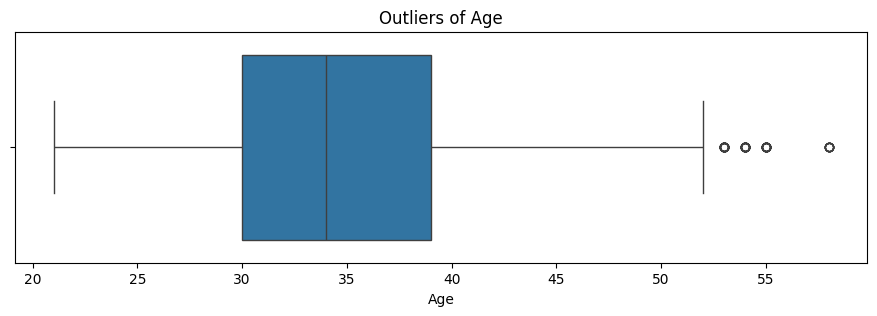

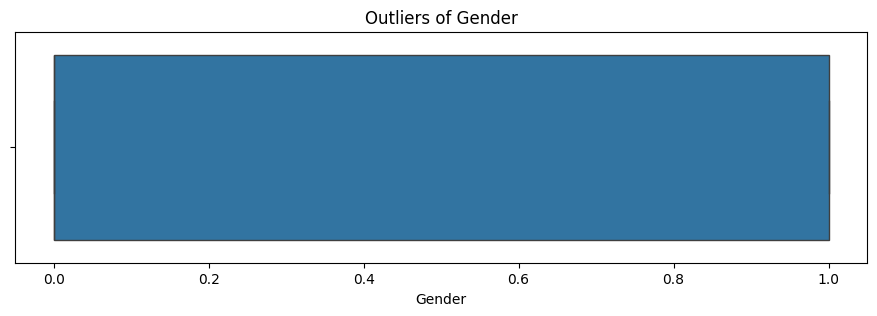

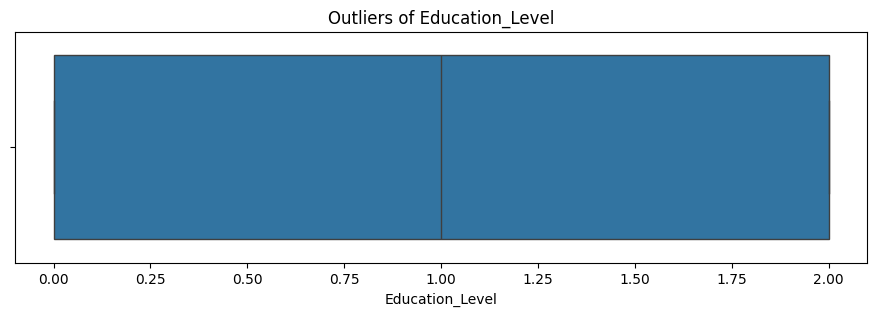

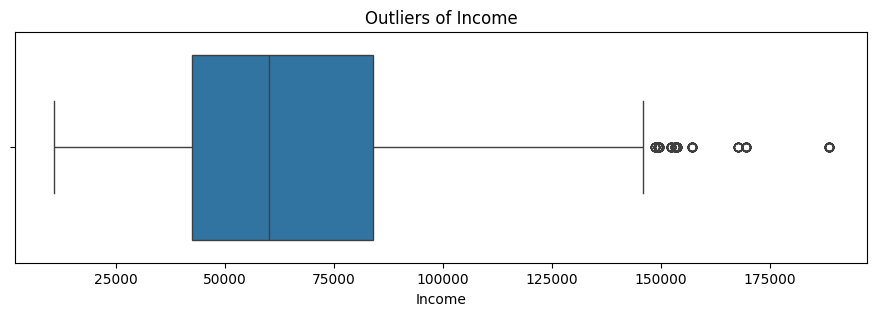

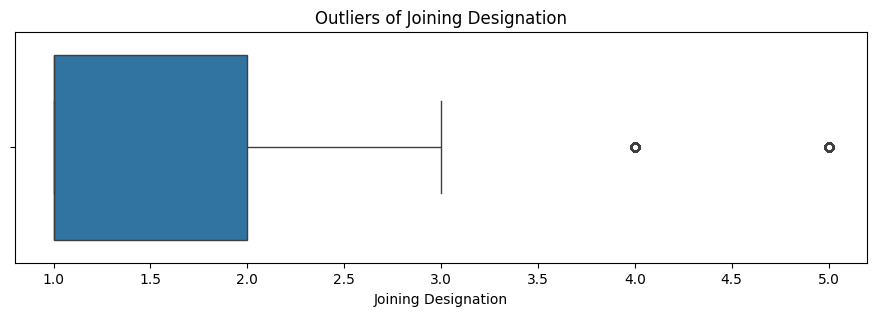

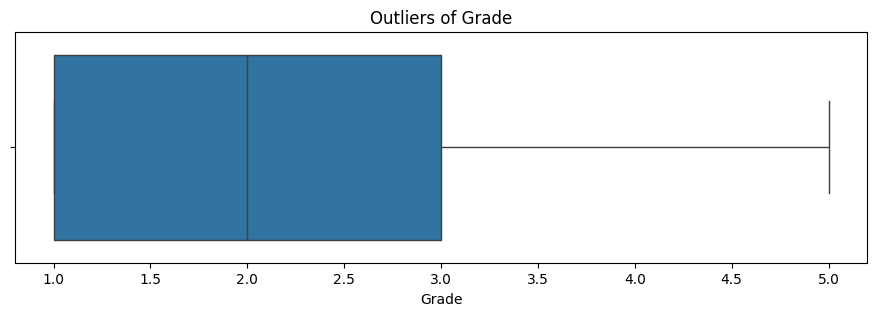

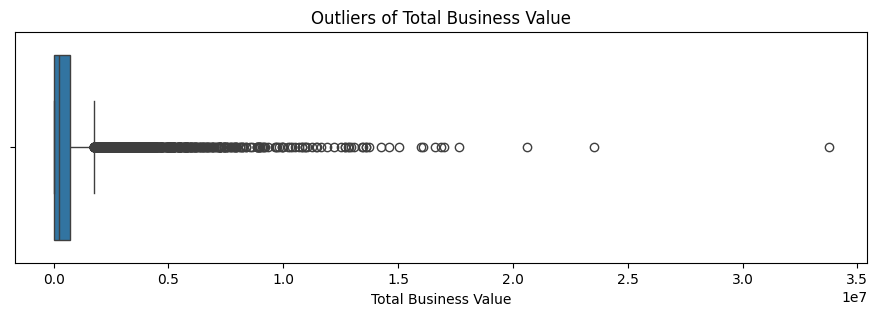

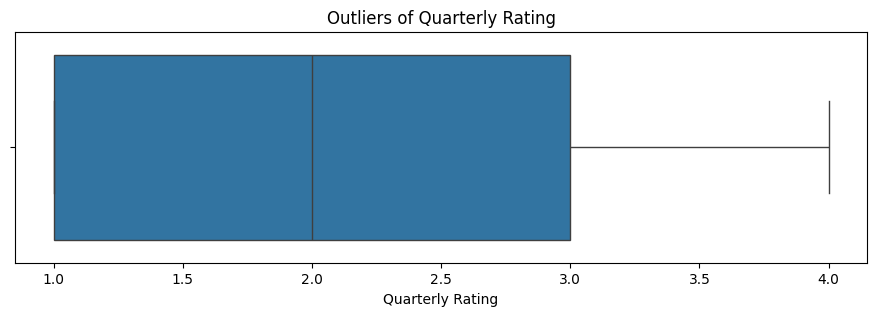

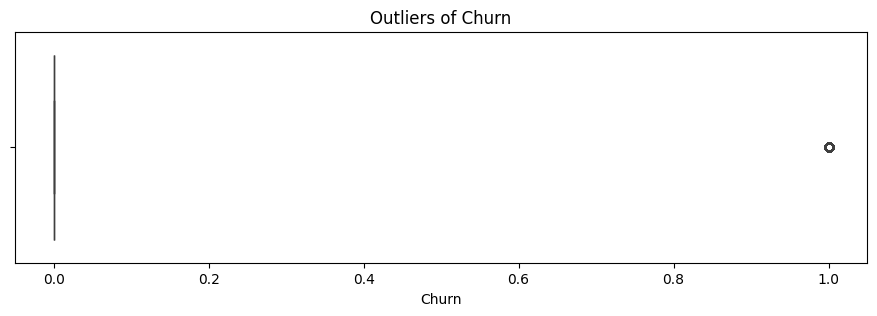

In [14]:
# #Lets see there is have outliers or not.

for i in numaric_feture:
    plt.figure(figsize=(11,3))
    sns.boxplot(x = df[i])
    plt.title(f"Outliers of {i}")
    plt.show()


In [15]:
print(f"Befor the Outliers remove we have a total column is {df.shape[0]}")

Befor the Outliers remove we have a total column is 19104


In [16]:
#Lets Remove the Outliers
temp = ["Income", "Total Business Value"]

for col in temp:
    for j in range(4):
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        
        IQR = Q3 - Q1
        
        low = Q1 - 1.5 * IQR
        high = Q3 + 1.5 * IQR
        
        df = df[(df[col] >= low) & (df[col] <= high)]
    
    print(f"Outliers removed from {col}")

Outliers removed from Income
Outliers removed from Total Business Value


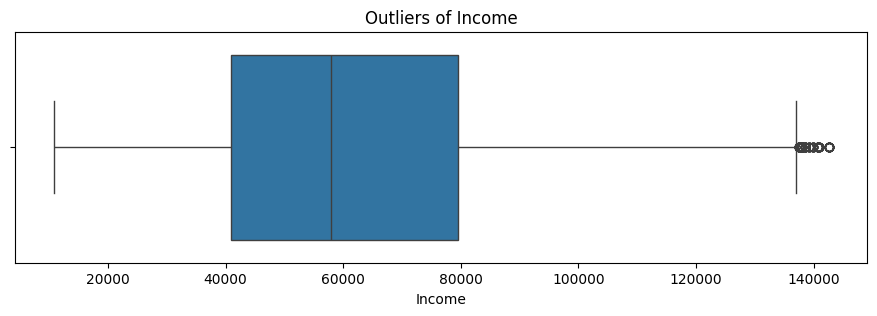

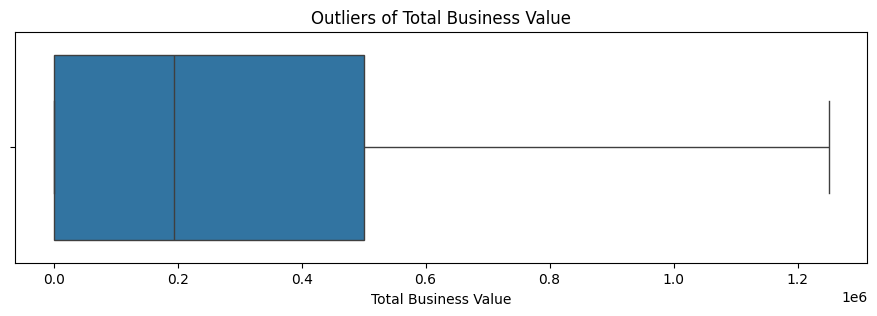

In [17]:
for i in temp:
    plt.figure(figsize=(11,3))
    sns.boxplot(x = df[i])
    plt.title(f"Outliers of {i}")
    plt.show()

In [18]:
print(f"Total rows in the data is {df.shape[0]}")

Total rows in the data is 16657


In [19]:
#Convert the Date to day,month,year vise.

df["Dateofjoining"] = pd.to_datetime(df["Dateofjoining"])

df['Year'] = df['Dateofjoining'].dt.year
df['Month'] = df['Dateofjoining'].dt.month
df['Day'] = df['Dateofjoining'].dt.day

df.drop('Dateofjoining',axis=1,inplace=True)

print("Data Convert into the Numaric formula and also remove the Date Of join columns.")



Data Convert into the Numaric formula and also remove the Date Of join columns.


C:\Users\Admin\AppData\Local\Temp\ipykernel_11852\3805775225.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Dateofjoining"] = pd.to_datetime(df["Dateofjoining"])


In [20]:
df.head()

,Age,Gender,Education_Level,Income,Joining Designation,Grade,Total Business Value,Quarterly Rating,Churn,Year,Month,Day
1,28,0.0,2,57387,1,1,665480,2,0,2018,12,24
2,28,0.0,2,57387,1,1,0,2,1,2018,12,24
3,31,0.0,2,67016,2,2,0,1,0,2020,11,6
4,31,0.0,2,67016,2,2,0,1,0,2020,11,6
5,43,0.0,2,65603,2,2,0,1,0,2019,12,7


In [21]:
#Reindex the columns

column_sequance = ["Age","Gender","Day","Month","Year","Education_Level","Income","Joining Designation","Grade","Total Business Value","Quarterly Rating","Churn"]

df = df.reindex(columns=column_sequance)

In [ ]:
#Make the saperate columns for X and Y.

try:
    x = df.iloc[:,:-1]
    y = df['Churn']

    # #Do the Train test split the data

    x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=42,test_size=0.2)

    print("Train Test completed...")
except Exception as e:
    print(f"Error : {e}")

Train Test completed...


In [ ]:
#Scal down the data for better performance.

try:
    std = StandardScaler()

    x_train_scaled = std.fit_transform(x_train)
    x_test_scaled = std.transform(x_test)

    print("Transformation is completed...")
except Exception as e2:
    print(f"Error : {2}")

Transformation is completed...


In [ ]:
#Use Logistic regression

try:

    lr = LogisticRegression()

    lr.fit(x_train_scaled,y_train)
    y_lr_predict = lr.predict(x_test_scaled)

    print("Accuracy Score :",round(accuracy_score(y_test,y_lr_predict)*100,2))
    print("Mean Absolute Error",mean_absolute_error(y_test,y_lr_predict))
    print("Mean Squared Error:",mean_squared_error(y_test,y_lr_predict))
    print("Root Mean Squared Error:",root_mean_squared_error(y_test,y_lr_predict))
    print("R2 Score:",r2_score(y_test,y_lr_predict))
except Exception as e1:
    print(f"Error {e1}.")

Accuracy Score : 90.43
Mean Absolute Error 0.09573829531812725
Mean Squared Error: 0.09573829531812725
Root Mean Squared Error: 0.30941605536579264
R2 Score: -0.10587454364420856


In [ ]:
#User Input Prediction Functions.

try:
    age = int(input("Enter Age: "))
    gender = int(input("Enter Gender (0 = Female, 1 = Male): "))
    day = int(input("Enter Joining Day: "))
    month = int(input("Enter Joining Month: "))
    year = int(input("Enter Joining Year: "))
    education_level = int(input("Enter Education Level: "))
    income = int(input("Enter Income: "))
    joining_designation = int(input("Enter Joining Designation: "))
    grade = int(input("Enter Grade: "))
    total_business_value = int(input("Enter Total Business Value: "))
    quarterly_rating = int(input("Enter Quarterly Rating: "))
except Exception as e2:
    print(f"Error {e2}.")
    
# age = 28
# gender = 0
# day = 24
# month = 12
# year = 2018
# education_level = 2
# income = 57387
# joining_designation = 1
# grade = 1
# total_business_value = 665480
# quarterly_rating = 2

new_df = pd.DataFrame([{
    "Age": age,
    "Gender": gender,
    "Day": day,
    "Month": month,
    "Year": year,
    "Education_Level": education_level,
    "Income": income,
    "Joining Designation": joining_designation,
    "Grade": grade,
    "Total Business Value": total_business_value,
    "Quarterly Rating": quarterly_rating
}])

temp3 =["Age","Gender","Day","Month","Year","Education_Level","Income",
        "Joining Designation","Grade","Total Business Value","Quarterly Rating"]

#Make the perfect data
for i in temp3:
    new_df[i] = pd.to_numeric(new_df[i],errors="coerce")
    new_df[i] = new_df[i].abs()

# Scale the input data
new_scald_df = std.transform(new_df)
print("Data scaling process completed...")

# Final Prediction
final_output = lr.predict(new_scald_df)[0]

ans = "Driving Status is on High Risk" if final_output==1 else "Driving Status is Safe"
print(ans)

Data scaling process completed...
Driving Status is Safe
